QUANTUM CNN MODEL USING SDG OPTIMIZER WITH MOMENTUM=0.9

In [1]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

In [2]:
# %pip install tensorflow[and-cuda] matplotlib numpy pandas scikit-learn seaborn pennylane opencv-python

In [3]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

2025-12-14 14:51:26.952625: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: # allow memory growth
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("GPU config error:", e)


In [5]:
import os
import time
import csv
import json
import gc
import warnings
from datetime import datetime

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.python.framework.errors_impl import ResourceExhaustedError
from tensorflow.keras.optimizers import Optimizer 
from tensorflow.keras.saving import register_keras_serializable
import pennylane as qml
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

In [6]:
# -------------------------
# Configuration
# -------------------------
IMG_SIZE = (64, 64)
BATCH_SIZE = 16
EPOCHS = 30  # Centralized training epochs
K_FOLDS = 5
NUM_CLASSES = 4
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
LEARNING_RATE=0.001
BETA=0.9
GAMMA=1e-7

# Quantum settings
N_QUBITS = 4
N_LAYERS = 2
TOTAL_SHOTS = 1000            
USE_NOISE = True
NOISE_PROB = 0.02     

In [7]:
# Create folders
os.makedirs("qcnn-logs", exist_ok=True)
os.makedirs("qcnn-models", exist_ok=True)
os.makedirs("qcnn-visuals", exist_ok=True)

# reproducibility
np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid", font_scale=1.1)

In [8]:
@register_keras_serializable(package="custom", name="AdamSGDHybrid")
class AdamSGDHybrid(tf.keras.optimizers.Optimizer):

    def __init__(
        self,
        learning_rate=0.001,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-7,
        momentum=0.9,
        mix_factor=0.5,
        name="AdamSGDHybrid",
        **kwargs
    ):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.momentum = momentum
        self.mix_factor = mix_factor

    def build(self, var_list):
        self.m = []
        self.v = []
        self.sgd_mom = []

        for var in var_list:
            self.m.append(self.add_variable_from_reference(var, "m"))
            self.v.append(self.add_variable_from_reference(var, "v"))
            self.sgd_mom.append(self.add_variable_from_reference(var, "sgd_mom"))

        super().build(var_list)

    def update_step(self, grad, var, lr):
        if grad is None:
            return

        idx = self._get_variable_index(var)

        m = self.m[idx]
        v = self.v[idx]
        sgd_mom = self.sgd_mom[idx]

        # Adam update
        m.assign(self.beta1 * m + (1. - self.beta1) * grad)
        v.assign(self.beta2 * v + (1. - self.beta2) * tf.square(grad))
        adam_update = m / (tf.sqrt(v) + self.epsilon)

        # SGD momentum update
        sgd_mom.assign(self.momentum * sgd_mom + grad)
        sgd_update = sgd_mom

        # Hybrid update
        update = self.mix_factor * adam_update + (1. - self.mix_factor) * sgd_update
        var.assign_sub(lr * update)

    def get_config(self):
        config = super().get_config()
        config.update({
            "beta1": self.beta1,
            "beta2": self.beta2,
            "epsilon": self.epsilon,
            "momentum": self.momentum,
            "mix_factor": self.mix_factor,
        })
        return config

In [9]:
# -------------------------
# Quantum circuit (with depolarizing noise)
# -------------------------
def quantum_circuit(inputs, weights):
    """
    Quantum circuit with encoding, optional depolarizing noise, variational layers and measurements.
    """
    # data encoding
    for i in range(N_QUBITS):
        qml.RY(inputs[i], wires=i)

    # optional depolarizing noise after encoding
    if USE_NOISE and NOISE_PROB > 0:
        for i in range(N_QUBITS):
            qml.DepolarizingChannel(NOISE_PROB, wires=i)

    # variational layers
    for layer in range(N_LAYERS):
        for i in range(N_QUBITS):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)

        # entanglement
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])

        # depolarizing noise between layers (optional)
        if USE_NOISE and NOISE_PROB > 0:
            for i in range(N_QUBITS):
                qml.DepolarizingChannel(NOISE_PROB, wires=i)

    # return expectation values
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]



In [10]:
# Helper: create a qnode with shots safely (handles deprecation across PL versions)
def make_qnode_with_shots(shots):
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=qml.PennyLaneDeprecationWarning)
            dev = qml.device("default.qubit", wires=N_QUBITS, shots=shots)
        qnode = qml.QNode(quantum_circuit, dev, interface='autograd')
        return qnode
    except Exception:
        try:
            dev = qml.device("default.qubit", wires=N_QUBITS)
            qnode = qml.QNode(quantum_circuit, dev, interface='autograd')
            try:
                from pennylane.transforms import set_shots
                qnode = set_shots(shots)(qnode)
                return qnode
            except Exception:
                return qnode
        except Exception:
            raise

In [11]:
# -------------------------
# QuantumInspiredLayer
# -------------------------
class QuantumInspiredLayer(layers.Layer):
    def __init__(self, n_qubits, n_layers, **kwargs):
        super().__init__(**kwargs)
        self.n_qubits = n_qubits
        self.n_layers = n_layers

    def build(self, input_shape):
        self.rotation_weights = self.add_weight(
            name="rotation_weights",
            shape=(self.n_layers, self.n_qubits, 2),
            initializer=keras.initializers.RandomUniform(0, 2*np.pi),
            trainable=True
        )
        self.interaction_weights = self.add_weight(
            name="interaction_weights",
            shape=(self.n_layers, self.n_qubits, self.n_qubits),
            initializer=keras.initializers.GlorotUniform(),
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        x = inputs
        for layer in range(self.n_layers):
            ry_transform = tf.cos(self.rotation_weights[layer, :, 0]) * x + \
                           tf.sin(self.rotation_weights[layer, :, 0]) * tf.roll(x, shift=1, axis=-1)
            rz_transform = tf.cos(self.rotation_weights[layer, :, 1]) * ry_transform - \
                           tf.sin(self.rotation_weights[layer, :, 1]) * tf.roll(ry_transform, shift=-1, axis=-1)
            interaction = tf.matmul(tf.expand_dims(rz_transform, -1), tf.expand_dims(rz_transform, -2))
            interaction_effect = tf.reduce_sum(interaction * self.interaction_weights[layer], axis=-1)
            x = tf.tanh(rz_transform + 0.1 * interaction_effect)
        return x

In [12]:

# -------------------------
# Sequence Data Loader (Kept for K-Fold utility)
# -------------------------
class ClientSequence(keras.utils.Sequence):
    def __init__(self, filepaths, labels, img_size=IMG_SIZE, batch_size=BATCH_SIZE, num_classes=NUM_CLASSES, shuffle=True):
        self.filepaths = np.array(filepaths)
        self.labels = np.array(labels)
        self.img_size = img_size
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def __getitem__(self, index):
        batch_idx = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_files = self.filepaths[batch_idx]
        batch_labels = self.labels[batch_idx]
        X = np.zeros((len(batch_files), *self.img_size, 3), dtype=np.float32)
        y = np.zeros((len(batch_files), self.num_classes), dtype=np.float32)
        for i, fp in enumerate(batch_files):
            img = cv2.imread(fp)
            if img is None:
                img = np.zeros((self.img_size[0], self.img_size[1], 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, self.img_size)
            img = img.astype(np.float32) / 255.0
            y[i, int(batch_labels[i])] = 1.0
            X[i] = img
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [13]:
# -------------------------
# Timing callback for epochs (Simplified for Centralized)
# -------------------------
class TimingCallback(Callback):
    def __init__(self, epoch_records):
        super().__init__()
        self.epoch_times = []
        self.epoch_records = epoch_records

    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        t = time.time() - self._start
        self.epoch_times.append(t)
        # safe get lr
        try:
            lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
            loss = float(logs["loss"])
        except Exception:
            lr = None
            loss=None
        train_acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')
        train_loss = logs.get('loss')
        val_loss = logs.get('val_loss')
        self.epoch_records.append([epoch+1, t, train_acc, val_acc, train_loss, val_loss, lr])
        print(f"⏱ Epoch {epoch+1} time={t:.2f}s train_acc={train_acc:.4f} val_acc={val_acc}")

In [14]:
# -------------------------
# Centralized Quantum CNN class
# -------------------------
class CentralizedQuantumCNN:
    def __init__(self, img_size=IMG_SIZE, num_classes=NUM_CLASSES, class_names=CLASS_NAMES):
        self.img_size = img_size
        self.num_classes = num_classes
        self.class_names = class_names
        self.n_qubits = N_QUBITS
        self.n_layers = N_LAYERS
        self.model = None
        self.history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

    def create_quantum_cnn_model(self):
        inputs = layers.Input(shape=(*self.img_size, 3))
        # conv blocks
        x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2,2))(x)
        x = layers.Dropout(0.25)(x)

        x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2,2))(x)
        x = layers.Dropout(0.25)(x)

        x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2,2))(x)
        x = layers.Dropout(0.25)(x)

        x = layers.Flatten()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.5)(x)

        x = layers.Dense(self.n_qubits, activation='tanh', name='quantum_input')(x)
        x = QuantumInspiredLayer(self.n_qubits, self.n_layers, name='quantum_layer')(x)
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)

        model = models.Model(inputs=inputs, outputs=outputs)
        
        model.compile(
            optimizer=AdamSGDHybrid(
                learning_rate=0.001,
                momentum=0.9,
                mix_factor=0.5   
            ),
            loss='categorical_crossentropy',
            metrics=['accuracy'],
            run_eagerly=True
        )
        return model

    def load_data_generators(self, train_dir, test_dir, batch_size=BATCH_SIZE):
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            horizontal_flip=True,
            zoom_range=0.2,
            fill_mode='nearest',
            validation_split=0.2
        )
        test_datagen = ImageDataGenerator(rescale=1./255)

        train_generator = train_datagen.flow_from_directory(train_dir, target_size=self.img_size,
                                                            batch_size=batch_size, class_mode='categorical',
                                                            subset='training', shuffle=True)
        val_generator = train_datagen.flow_from_directory(train_dir, target_size=self.img_size,
                                                          batch_size=batch_size, class_mode='categorical',
                                                          subset='validation', shuffle=False)
        test_generator = test_datagen.flow_from_directory(test_dir, target_size=self.img_size,
                                                          batch_size=batch_size, class_mode='categorical',
                                                          shuffle=False)
        idx_to_class = {v:k for k,v in train_generator.class_indices.items()}
        self.class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
        return train_generator, val_generator, test_generator

    def train_centralized(self, train_generator, val_generator, epochs=EPOCHS, total_shots=TOTAL_SHOTS):
        print("\n========== CENTRALIZED QUANTUM CNN TRAINING STARTED ==========")
        print(f"Epochs: {epochs}, Shots: {total_shots}")

        self.model = self.create_quantum_cnn_model()

        # Logs
        epoch_records = []    # [epoch, time, train_acc, val_acc, train_loss, val_loss, lr]
        
        # Callbacks
        timing_cb = TimingCallback(epoch_records)
        callbacks = [
            timing_cb, 
            EarlyStopping(patience=5, restore_best_weights=True, verbose=1, monitor='val_loss'),
            ReduceLROnPlateau(factor=0.5, patience=3, verbose=1, monitor='val_loss')
        ]

        start_time = time.time()
        try:
            # We initialize a qnode for side effects/demo if needed, though mostly handled inside logic
            _ = make_qnode_with_shots(total_shots)
            
            history = self.model.fit(
                train_generator,
                validation_data=val_generator,
                epochs=epochs,
                verbose=1,
                callbacks=callbacks
            )
            self.history = history.history
        except ResourceExhaustedError as oom:
            print(" !! OOM on training:", oom)
            tf.keras.backend.clear_session()
            gc.collect()
            raise

        total_time = time.time() - start_time
        print(f"Total training time: {total_time:.2f}s")

        # Save logs to CSV
        epoch_csv = os.path.join("qcnn-logs", "centralized_epoch_times.csv")
        with open(epoch_csv, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["Epoch", "TimeSec", "TrainAcc", "ValAcc", "TrainLoss", "ValLoss", "LR"])
            w.writerows(epoch_records)
        print(f"Saved epoch-level logs: {epoch_csv}")

        # Summary JSON
        summary = {
            "timestamp": datetime.now().isoformat(),
            "epochs": epochs,
            "total_shots": total_shots,
            "training_time_sec": total_time,
            "final_val_acc": float(self.history['val_accuracy'][-1]),
            "final_val_loss": float(self.history['val_loss'][-1]),
            "noise": {"use_noise": USE_NOISE, "noise_prob": NOISE_PROB}
        }
        with open(os.path.join("qcnn-logs", "centralized_run_summary.json"), "w") as f:
            json.dump(summary, f, indent=2)
        print("Saved run summary JSON")

        return self.model

    def kfold_cross_validation(self, train_dir, k_folds=K_FOLDS, batch_size=BATCH_SIZE):
        print("\nK-FOLD CROSS-VALIDATION (Quantum CNN)")

        datagen = ImageDataGenerator(rescale=1./255)
        full_gen = datagen.flow_from_directory(
            train_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=False
        )

        filepaths = np.array(full_gen.filepaths)
        labels = np.array(full_gen.classes, dtype=int)

        kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
        fold_scores = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(filepaths)):
            print(f"\n-- Fold {fold+1}/{k_folds} --")
            tf.keras.backend.clear_session()
            train_seq = ClientSequence(
                filepaths[train_idx],
                labels[train_idx],
                img_size=self.img_size,
                batch_size=batch_size,
                num_classes=self.num_classes,
                shuffle=True
            )

            val_seq = ClientSequence(
                filepaths[val_idx],
                labels[val_idx],
                img_size=self.img_size,
                batch_size=batch_size,
                num_classes=self.num_classes,
                shuffle=False
            )

            model = self.create_quantum_cnn_model()

            model.fit(
                train_seq,
                validation_data=val_seq,
                epochs=30,
                callbacks=[
                    EarlyStopping(patience=5, restore_best_weights=True),
                    ReduceLROnPlateau(patience=3)
                ],
                verbose=1
            )

            _, acc = model.evaluate(val_seq, verbose=0)
            fold_scores.append(float(acc))
            print(f"Fold {fold+1} Accuracy: {acc:.4f}")
            
            tf.keras.backend.clear_session()
            del model
            gc.collect()

        return fold_scores


    def evaluate_model(self, test_generator):
        print("\nEVALUATING ON TEST SET")
        y_pred_probs = self.model.predict(test_generator, verbose=1)
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true = test_generator.classes
        acc = accuracy_score(y_true, y_pred)
        print(f"Test Accuracy: {acc:.4f}")
        report = classification_report(y_true, y_pred, target_names=self.class_names, digits=4)
        print(report)
        # save classification report
        with open(os.path.join("qcnn-logs", "classification_report.txt"), "w") as f:
            f.write(report)
        cm = confusion_matrix(y_true, y_pred)
        # per-class metrics
        precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)
        for i, cname in enumerate(self.class_names):
            print(f"{cname}: prec={precision[i]:.4f} rec={recall[i]:.4f} f1={f1[i]:.4f} sup={support[i]}")
        return y_true, y_pred, y_pred_probs, cm, acc

    def plot_training_history(self):
        # validation accuracy / loss
        if not self.history.get('val_accuracy'):
            return
        fig, ax = plt.subplots(1,2, figsize=(14,5))
        ax[0].plot(self.history['accuracy'], label='Train Acc', marker='.')
        ax[0].plot(self.history['val_accuracy'], label='Val Acc', marker='o')
        ax[0].set_title('Accuracy'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Accuracy'); ax[0].grid(True); ax[0].legend()
        
        ax[1].plot(self.history['loss'], label='Train Loss', marker='.')
        ax[1].plot(self.history['val_loss'], label='Val Loss', marker='o')
        ax[1].set_title('Loss'); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Loss'); ax[1].grid(True); ax[1].legend()
        plt.tight_layout(); plt.savefig('qcnn-visuals/qcnn_training_history.png', dpi=300, bbox_inches='tight'); plt.show()
        print("Saved qcnn-visuals/qcnn_training_history.png")

    def plot_confusion_matrix(self, cm):
        plt.figure(figsize=(9,7))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=self.class_names, yticklabels=self.class_names)
        plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
        plt.tight_layout(); plt.savefig('qcnn-visuals/qcnn_confusion_matrix.png', dpi=300, bbox_inches='tight'); plt.show()
        print("Saved qcnn-visuals/qcnn_confusion_matrix.png")

    def plot_performance_metrics(self, y_true, y_pred):
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
        x = np.arange(len(self.class_names)); w=0.25
        fig, ax = plt.subplots(figsize=(10,5))
        ax.bar(x-w, precision, w, label='Precision'); ax.bar(x, recall, w, label='Recall'); ax.bar(x+w, f1, w, label='F1')
        ax.set_xticks(x); ax.set_xticklabels(self.class_names, rotation=45); ax.set_ylim([0,1.05]); ax.legend()
        plt.tight_layout(); plt.savefig('qcnn-visuals/qcnn_performance_metrics.png', dpi=300, bbox_inches='tight'); plt.show()
        print("Saved qcnn-visuals/qcnn_performance_metrics.png")

    def visualize_quantum_layer(self, test_generator, num_samples=4):
        print("Visualizing quantum layer activations...")
        quantum_model = keras.Model(inputs=self.model.input, outputs=self.model.get_layer('quantum_layer').output)
        # sample some images
        test_images = []
        test_labels = []
        it = iter(test_generator)
        for _ in range(num_samples):
            try:
                bx, by = next(it)
            except StopIteration:
                it = iter(test_generator); bx, by = next(it)
            test_images.append(bx[0]); test_labels.append(np.argmax(by[0]))
        fig, axes = plt.subplots(num_samples, 2, figsize=(12,3*num_samples))
        for i in range(num_samples):
            img = np.expand_dims(test_images[i], axis=0)
            qout = quantum_model.predict(img, verbose=0)[0]
            axes[i,0].imshow(test_images[i]); axes[i,0].axis('off'); axes[i,0].set_title(f"Input: {self.class_names[test_labels[i]]}")
            axes[i,1].bar(range(self.n_qubits), qout); axes[i,1].set_ylim([-1,1]); axes[i,1].set_title('Quantum Layer Activations')
        plt.tight_layout(); plt.savefig('qcnn-visuals/qcnn_quantum_activations.png', dpi=300, bbox_inches='tight'); plt.show()
        print("Saved qcnn-visuals/qcnn_quantum_activations.png")

    def save_results(self, fold_scores, test_accuracy):
        results = {
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'model': 'Centralized Quantum CNN',
            'kfold': { 'fold_scores': fold_scores, 'mean': float(np.mean(fold_scores)), 'std': float(np.std(fold_scores)) },
            'test_accuracy': float(test_accuracy),
            'training_history': self.history
        }
        with open('qcnn-logs/centralized_quantum_cnn_results.json', 'w') as f:
            json.dump(results, f, indent=2)
        print("Saved logs/centralized_quantum_cnn_results.json")
        

In [15]:
# MAIN
# -------------------------
def main():
    TRAIN_DIR = '/mnt/c/Users/hassa/OneDrive/Desktop/QML/Brain_Tumor_data/Training'
    TEST_DIR = '/mnt/c/Users/hassa/OneDrive/Desktop/QML/Brain_Tumor_data/Testing'
    
    qcnn = CentralizedQuantumCNN(img_size=IMG_SIZE)
    train_gen, val_gen, test_gen = qcnn.load_data_generators(TRAIN_DIR, TEST_DIR, batch_size=BATCH_SIZE)
    print(f"Dataset: train {train_gen.samples}, val {val_gen.samples}, test {test_gen.samples}")

    # Phase 1: K-Fold cross validation
    start = time.time()
    fold_scores = qcnn.kfold_cross_validation(TRAIN_DIR, k_folds=K_FOLDS, batch_size=BATCH_SIZE)
    print(f"K-fold time: {time.time()-start:.2f}s")

    # Phase 2: Centralized Training
    start = time.time()
    qcnn.train_centralized(train_gen, val_gen, epochs=EPOCHS, total_shots=TOTAL_SHOTS)
    print(f"Centralized training time: {time.time()-start:.2f}s")

    qcnn.plot_training_history()

    # Phase 3: Evaluate
    y_true, y_pred, y_pred_probs, cm, test_acc = qcnn.evaluate_model(test_gen)
    qcnn.plot_confusion_matrix(cm)
    qcnn.plot_performance_metrics(y_true, y_pred)
    qcnn.visualize_quantum_layer(test_gen, num_samples=4)

    qcnn.save_results(fold_scores, test_acc)

    # Save final model
    try:
        qcnn.model.save('qcnn-models/centralized_quantum_brain_tumor_model.keras')
        print("Saved final model to qcnn-models/centralized_quantum_brain_tumor_model.keras")
    except Exception as e:
        print("Could not save final model:", e)



Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Dataset: train 4571, val 1141, test 1311

K-FOLD CROSS-VALIDATION (Quantum CNN)
Found 5712 images belonging to 4 classes.

-- Fold 1/5 --


I0000 00:00:1765723982.815836   14603 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6
/mnt/c/Users/hassa/OneDrive/Desktop/QML/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


/mnt/c/Users/hassa/OneDrive/Desktop/QML/.venv/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
2025-12-14 14:53:06.176394: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700


286/286 ━━━━━━━━━━━━━━━━━━━━ 81s 246ms/step - accuracy: 0.2948 - loss: 1.4033 - val_accuracy: 0.2546 - val_loss: 1.3898 - learning_rate: 0.0010
Epoch 2/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 67s 234ms/step - accuracy: 0.3563 - loss: 1.3428 - val_accuracy: 0.3928 - val_loss: 1.4042 - learning_rate: 0.0010
Epoch 3/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 70s 244ms/step - accuracy: 0.4058 - loss: 1.2883 - val_accuracy: 0.2572 - val_loss: 1.3692 - learning_rate: 0.0010
Epoch 4/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 66s 230ms/step - accuracy: 0.4465 - loss: 1.2355 - val_accuracy: 0.4077 - val_loss: 1.1975 - learning_rate: 0.0010
Epoch 5/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 66s 232ms/step - accuracy: 0.5222 - loss: 1.1815 - val_accuracy: 0.6028 - val_loss: 1.0686 - learning_rate: 0.0010
Epoch 6/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 66s 231ms/step - accuracy: 0.5301 - loss: 1.1518 - val_accuracy: 0.3246 - val_loss: 1.7415 - learning_rate: 0.0010
Epoch 7/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 70s 244ms/step - accuracy: 0.4900 - loss:

/mnt/c/Users/hassa/OneDrive/Desktop/QML/.venv/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.3310 - loss: 1.3801⏱ Epoch 1 time=72.12s train_acc=0.4087 val_acc=0.45486414432525635
286/286 ━━━━━━━━━━━━━━━━━━━━ 72s 251ms/step - accuracy: 0.4087 - loss: 1.3184 - val_accuracy: 0.4549 - val_loss: 1.2040 - learning_rate: 0.0010
Epoch 2/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.4744 - loss: 1.2154⏱ Epoch 2 time=71.89s train_acc=0.4719 val_acc=0.37686240673065186
286/286 ━━━━━━━━━━━━━━━━━━━━ 72s 251ms/step - accuracy: 0.4719 - loss: 1.2119 - val_accuracy: 0.3769 - val_loss: 1.4369 - learning_rate: 0.0010
Epoch 3/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.4529 - loss: 1.2148⏱ Epoch 3 time=68.94s train_acc=0.4730 val_acc=0.3032427728176117
286/286 ━━━━━━━━━━━━━━━━━━━━ 69s 241ms/step - accuracy: 0.4730 - loss: 1.1748 - val_accuracy: 0.3032 - val_loss: 1.3938 - learning_rate: 0.0010
Epoch 4/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.4856 - loss: 1.1519⏱ Epoch 4 time=73.56s train_acc

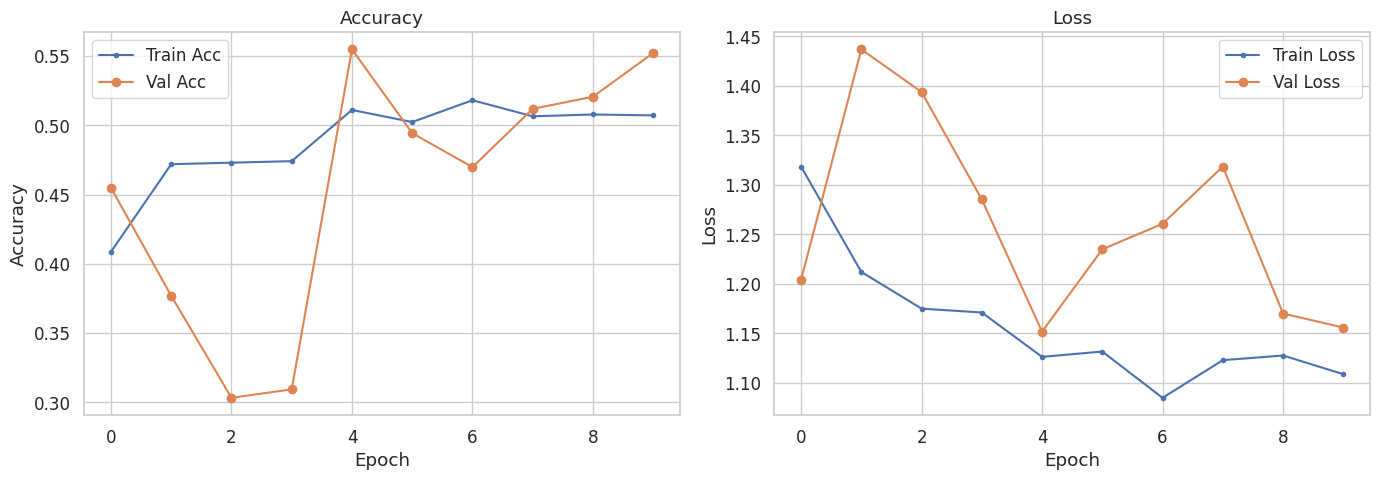

Saved qcnn-visuals/qcnn_training_history.png

EVALUATING ON TEST SET
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step
Test Accuracy: 0.5210
              precision    recall  f1-score   support

      glioma     0.6450    0.4967    0.5612       300
  meningioma     0.2835    0.1176    0.1663       306
     notumor     0.4886    0.8444    0.6190       405
   pituitary     0.6166    0.5200    0.5642       300

    accuracy                         0.5210      1311
   macro avg     0.5084    0.4947    0.4777      1311
weighted avg     0.5058    0.5210    0.4876      1311

glioma: prec=0.6450 rec=0.4967 f1=0.5612 sup=300
meningioma: prec=0.2835 rec=0.1176 f1=0.1663 sup=306
notumor: prec=0.4886 rec=0.8444 f1=0.6190 sup=405
pituitary: prec=0.6166 rec=0.5200 f1=0.5642 sup=300


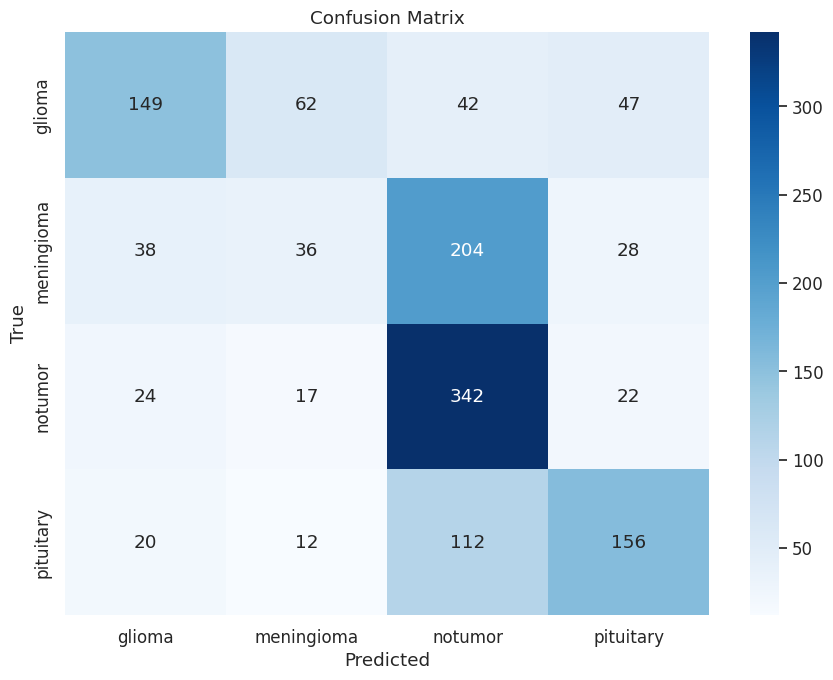

Saved qcnn-visuals/qcnn_confusion_matrix.png


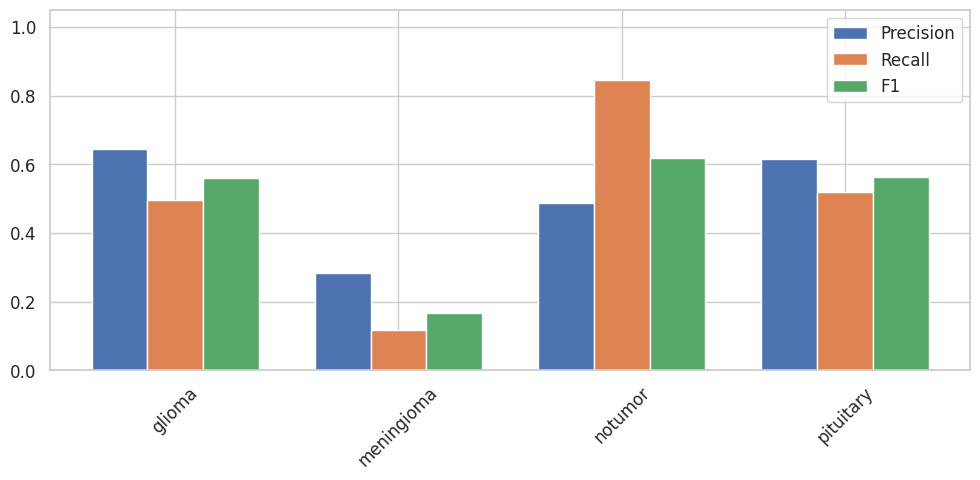

Saved qcnn-visuals/qcnn_performance_metrics.png
Visualizing quantum layer activations...


/mnt/c/Users/hassa/OneDrive/Desktop/QML/.venv/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


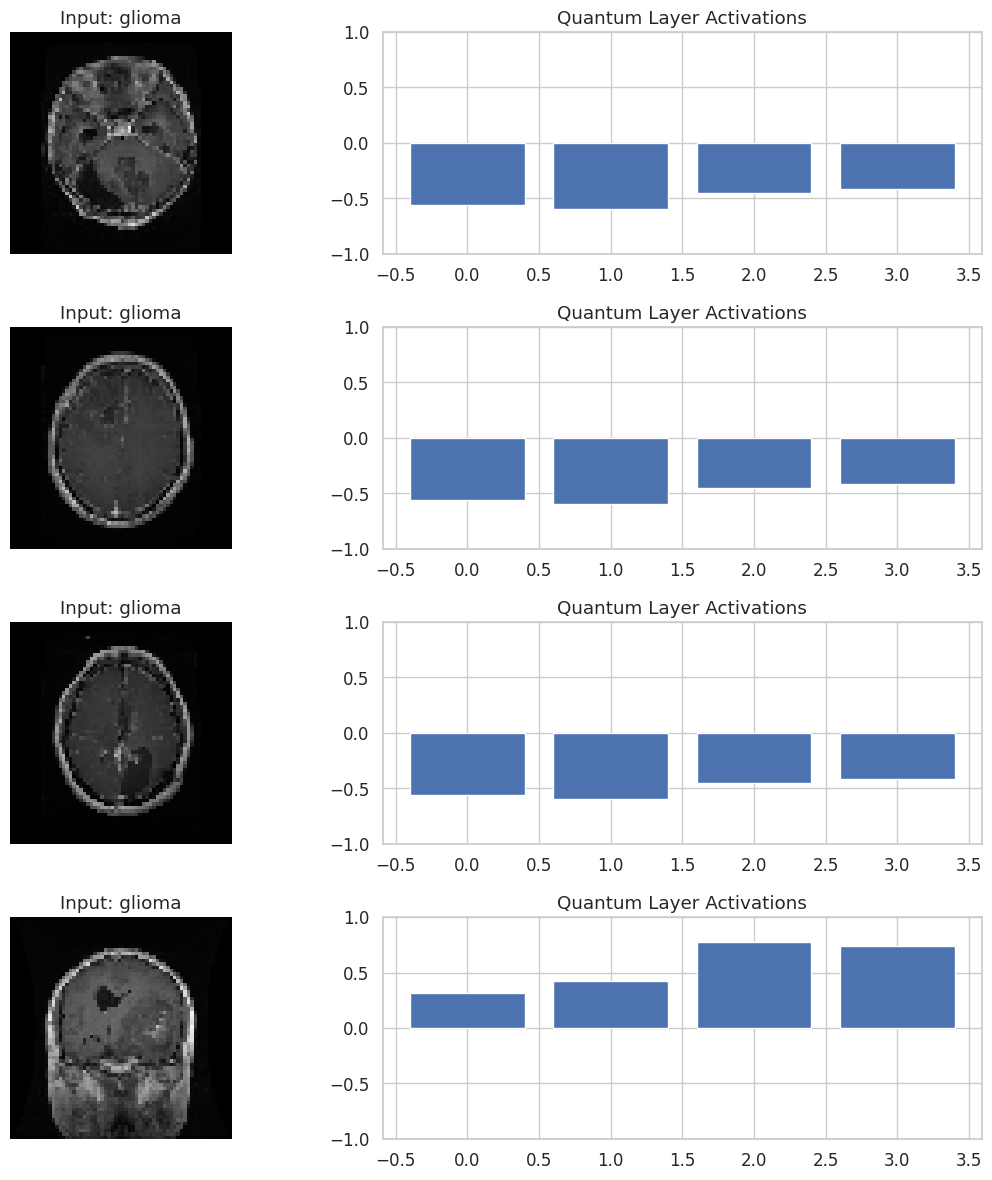

Saved qcnn-visuals/qcnn_quantum_activations.png
Saved logs/centralized_quantum_cnn_results.json
Saved final model to qcnn-models/centralized_quantum_brain_tumor_model.keras


In [16]:
if __name__ == "__main__":
    main()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import FuncFormatter

sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)


In [ ]:
epoch_df = pd.read_csv("/mnt/c/Users/hassa/OneDrive/Desktop/QML/qcnn-logs/centralized_epoch_times.csv")
# round_df = pd.read_csv("flq-logs/federated_round_summary.csv")
# comm_df = pd.read_csv("flq-logs/comm_bytes_per_round.csv")

print("Epoch Data:", epoch_df.shape)
# print("Round Data:", round_df.shape)
# print("Comm Data:", comm_df.shape)


Epoch Data: (10, 7)


In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df, 
    x='Epoch', y='TrainAcc', 
    hue='Fold', 
    marker='o', 
    palette='viridis', 
    alpha=0.8, 
    linewidth=2
)
sns.lineplot(
    data=df, 
    x='Epoch', y='ValAcc', 
    hue='Fold', 
    marker='s', 
    palette='magma', 
    alpha=0.8, 
    linewidth=2,
    legend=False
)

plt.title("Training vs Validation Accuracy Across Folds (QCNN)", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(title='Fold', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



KeyboardInterrupt



In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Epoch', y='TrainLoss', hue='Fold', palette='cool', linewidth=2, marker='o')
sns.lineplot(data=df, x='Epoch', y='ValLoss', hue='Fold', palette='rocket', linewidth=2, linestyle='--', marker='s', legend=False)

plt.title("Training vs Validation Loss (QCNN)", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(title='Fold', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Epoch', y='TimeSec', hue='Fold', palette='Spectral')
plt.title("Training Time per Epoch across Folds", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Time (seconds)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [ ]:
fig = px.line(
    df, 
    x='Epoch', 
    y=['TrainAcc', 'ValAcc'], 
    color_discrete_sequence=['#1f77b4', '#ff7f0e'],
    title='QCNN Training and Validation Accuracy (Interactive)',
    markers=True
)
fig.update_layout(
    template='plotly_dark',
    xaxis_title='Epoch',
    yaxis_title='Accuracy',
    legend_title_text='Metric',
    font=dict(size=12)
)
fig.show()


In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['TrainAcc','ValAcc','TrainLoss','ValLoss','TimeSec','LR']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Training Metrics", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
summary = df.groupby('Fold')[['TrainAcc','ValAcc','TrainLoss','ValLoss','TimeSec']].agg(['mean','max','min'])
display(summary)


In [ ]:
from tensorflow.keras.models import load_model

model=load_model("quantum_cnn_brain_tumor_model.keras",  custom_objects={"QuantumInspiredLayer": QuantumInspiredLayer})
model.summary()